# CDC through navi's clients — Socrata and WONDER, no server in between

CDC arrives through two very different doors, so navi ships two clients.
`CdcClient` wraps the Socrata (SODA) portal at `data.cdc.gov`: an open JSON API,
one query language (SoQL) over a few thousand datasets with wildly inconsistent
schemas. `WonderClient` wraps CDC WONDER, the vital-statistics mortality
service, which answers an XML POST with an XML `<data-table>` and is rate
limited to roughly one query every two minutes behind a bot filter.

`walkthrough.ipynb` runs the same discover, fetch and plot arc through the MCP
server. This one calls the clients directly, so **the MCP server does not need
to be running** — only the vendor's credentials need to be configured, and CDC
is the easy case there: Socrata reads need **no key** (the optional
`CDC_API_KEY` app token only raises the rate limit) and WONDER's only gate is
`accept_datause_restrictions=true`, which the client always sends.

Two things are visible from here that the server route hides: **SoQL**, which
the `cdc_series_data` tool deliberately does not expose, and the **raw
payloads** the typed models are built from.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("../")        # notebooks/<source>/utils.py
sys.path.append("../../")     # the repo root, for meida's own mcp_server package

import json
import xml.etree.ElementTree as ElementTree
from pathlib import Path

from matplotlib import pyplot

from lib import config
from clients import CdcClient
from clients.wonder import _SKELETONS, _build_request_xml
from mcp_server.wonder_source import WonderNotStoredError, WonderSourceClient

from utils import (
    cdc_rows_to_arrays_with_dropped,
    plot_cdc_arrays,
    plot_stored_series,
)

pyplot.style.use(config.glyfish_style)

## 1. Discovery

Socrata's catalog is a real search endpoint, and it does not live on the portal:
`discover()`, `categories()` and `tags()` all hit `api.us.socrata.com`, the
cross-domain catalog host, filtered to the `data.cdc.gov` domain. Only the data
and schema calls go to the portal itself. Both come back as typed models —
`CdcCategory`, `CdcCatalogEntry` — rather than as raw catalog JSON.

In [2]:
cdc = CdcClient()

categories = await cdc.categories()
print(f"{len(categories)} categories on data.cdc.gov; the largest:")
for category in sorted(categories, key=lambda item: -item.count)[:6]:
    print(f"  {category.count:>5}  {category.category}")

hits = await cdc.discover("infant mortality", limit=10)
print(f"\ndiscover('infant mortality') -> {len(hits)} datasets")
for hit in hits:
    print(f"  {hit.id:12s} {hit.name}")


55 categories on data.cdc.gov; the largest:
    295  NNDSS
    287  National Center for Health Statistics
    177  National Institute for Occupational Safety and Health
     89  Vaccinations
     74  Public Health Surveillance
     67  500 Cities & Places

discover('infant mortality') -> 10 datasets
  jqwm-z2g9    NCHS - VSRR Quarterly provisional estimates for infant mortality
  ddsk-zebd    NCHS - Infant Mortality Rates, by Race: United States, 1915-2013
  pjb2-jvdr    DQS Infant mortality rates, by race and Hispanic origin of mother, state, and territory: United States and U.S. dependent areas (Archived)
  j7ym-uwqy    DQS Infant, neonatal, and postneonatal mortality rates, by detailed race and Hispanic origin of mother: United States
  epev-k6ss    NCHS - Infant and neonatal mortality rates: United States, 1915-2013
  nfuu-hu6j    Infant, neonatal, postneonatal, fetal, and perinatal mortality rates, by detailed race and Hispanic origin of mother: United States
  hmz2-vwda    VSRR -

WONDER has no catalog to search. What stands in for discovery is the client's
own captured request skeletons: WONDER validates the *full* parameter set on
every request and numbers its variables differently per database, so a database
is reachable only once its skeleton has been transcribed and verified against
published NCHS figures. Two have been — `D76` (bridged race, 1999–2020) and
`D158` (single race, final, 2018–2024) — and `_SKELETONS` is the honest list of
what the client can address today.

The other half of a WONDER query is not an identifier at all but a set of
underlying-cause ICD-10 codes. The client stays generic about which codes
constitute a concept — that belongs with the catalog, not the transport — so the
notebook supplies them.

In [3]:
print("WONDER databases with a captured request skeleton:", sorted(_SKELETONS))

# NCHS "drug overdose deaths" = these underlying-cause ICD-10 codes
# (NVSR 70-08, Technical Notes p.74): unintentional, suicide, homicide and
# undetermined poisoning by drugs.
DRUG_OVERDOSE_ICD10 = [
    "X40", "X41", "X42", "X43", "X44",
    "X60", "X61", "X62", "X63", "X64",
    "X85", "Y10", "Y11", "Y12", "Y13", "Y14",
]
print(f"{len(DRUG_OVERDOSE_ICD10)} ICD-10 codes define the concept")

WONDER databases with a captured request skeleton: ['D158', 'D76']
16 ICD-10 codes define the concept


## 2. Retrieving a series

### Socrata — read the schema first

Socrata is one API over many datasets with no shared schema, so the time, value
and facet columns have to be learned per dataset before a query can be written.
`columns()` reads `/api/views/{id}.json`. Calling the client's private `_get`
with the same path — reaching under the client on purpose — shows what that
endpoint actually returns, next to what the model keeps.

In [4]:
entry = next(hit for hit in hits if "Infant Mortality Rates, by Race" in (hit.name or ""))
print(f"{entry.id}: {entry.name}")

raw_view = (await cdc._get(f"/api/views/{entry.id}.json")).json()
raw_race = next(column for column in raw_view["columns"] if column["fieldName"] == "race")

print(f"\nraw /api/views payload: {len(raw_view)} top-level keys")
print(f"raw column keys: {sorted(raw_race)}\n")
print(json.dumps(raw_race, indent=2))

ddsk-zebd: NCHS - Infant Mortality Rates, by Race: United States, 1915-2013

raw /api/views payload: 43 top-level keys
raw column keys: ['cachedContents', 'dataTypeName', 'fieldName', 'format', 'id', 'name', 'position', 'renderTypeName', 'tableColumnId', 'width']

{
  "id": 260067085,
  "name": "Race",
  "dataTypeName": "text",
  "fieldName": "race",
  "position": 1,
  "renderTypeName": "text",
  "tableColumnId": 29760176,
  "width": 148,
  "cachedContents": {
    "largest": "White",
    "non_null": "198",
    "null": "0",
    "top": [
      {
        "item": "White",
        "count": "99"
      },
      {
        "item": "Black",
        "count": "98"
      },
      {
        "item": "Black ",
        "count": "1"
      }
    ],
    "smallest": "Black",
    "count": "198",
    "cardinality": "3"
  },
  "format": {}
}


In [5]:
dataset = await cdc.columns(entry.id)
print(f"{type(dataset).__name__}: {dataset.id} — {dataset.name}\n")
for column in dataset.columns:
    print(f"  {column.field_name:22s} {column.data_type:7s} {column.name}")

race = next(column for column in dataset.columns if column.field_name == "race")
print(f"\ncached_top -> {race.cached_top}")
raw_count = raw_race["cachedContents"]["top"][0]["count"]
print(f"count cast: raw {raw_count!r} ({type(raw_count).__name__})"
      f" -> model {race.cached_top[0]['count']!r} ({type(race.cached_top[0]['count']).__name__})")


CdcDataset: ddsk-zebd — NCHS - Infant Mortality Rates, by Race: United States, 1915-2013

  race                   text    Race
  year                   number  Year
  infant_mortality_rate  number  Infant Mortality Rate

cached_top -> [{'item': 'White', 'count': 99}, {'item': 'Black', 'count': 98}, {'item': 'Black ', 'count': 1}]
count cast: raw '99' (str) -> model 99 (int)


The raw view payload is 43 top-level keys of portal furniture — grants,
approvals, view counts, render types — and the columns inside it are camelCase
with every statistic stringified. `CdcDataset` is four fields, and each
`CdcColumn` is a validated shape: `fieldName` becomes `field_name`,
`dataTypeName` becomes `data_type`, and the nested `cachedContents` is flattened
into `cached_top` / `cached_smallest` / `cached_largest` / `cached_non_null` /
`cached_null` with the counts cast from `"99"` to `99`. A column carrying no
`fieldName` is dropped rather than kept as a half-row, and `cardinality` is
deliberately not surfaced: it is the distinct count on some datasets and the row
count on others, so it cannot be trusted to say whether `cached_top` is
complete.

`cached_top` earns the trip on its own. It carries the exact literals a SoQL
`where` needs, which are otherwise unguessable — and here it exposes a defect in
the data: the race column holds `"Black"` **and** `"Black "` with a trailing
space.

### SoQL — the layer the MCP tool does not expose

`cdc_series_data` takes named facets (`state`, `race`, `sex`) and never a query
string: the server owns the column names and literals, which is what lets one
tool span datasets that spell the same facet three different ways. The client is
the layer underneath, and it takes SoQL directly — `select`, `where`, `group`,
`order`, `limit` — which is what you want for a dataset the catalog has never
heard of, or for a `$group=` question no fetch tool asks.

A `group` query is also the only exhaustive way to enumerate a column's values,
because Socrata caps `cached_top` at 20.

In [6]:
distinct = await cdc.query(
    entry.id,
    select="race, count(*) AS rows, min(year) AS first_year, max(year) AS last_year",
    group="race",
    order="race",
)
for row in distinct.rows:
    print(f"  {row['race']!r:10s} {row['rows']:>4s} rows  {row['first_year']}..{row['last_year']}")


  'Black'      98 rows  1915..2012
  'Black '      1 rows  2013..2013
  'White'      99 rows  1915..2013


In [7]:
strict = await cdc.query(entry.id, where="race='Black'", order="year", limit=5000)
black = await cdc.query(entry.id, where="starts_with(race, 'Black')", order="year", limit=5000)

print(f"where race='Black'              -> {strict.row_count} rows, last {strict.rows[-1]['year']}")
print(f"where starts_with(race,'Black') -> {black.row_count} rows, last {black.rows[-1]['year']}")

# the same query one layer down: a bare JSON array of {field: string}
raw_rows = (await cdc._get(
    f"/resource/{entry.id}.json",
    {"$where": "starts_with(race, 'Black')", "$order": "year", "$limit": 2},
)).json()
print(f"\nraw   {type(raw_rows).__name__}: {raw_rows}")
print(f"typed {type(black).__name__}: dataset_id={black.dataset_id!r},"
      f" row_count={black.row_count}, rows[0]={black.rows[0]}")

await cdc.aclose()   # no further Socrata requests below

where race='Black'              -> 98 rows, last 2012
where starts_with(race,'Black') -> 99 rows, last 2013

raw   list: [{'race': 'Black', 'year': '1915', 'infant_mortality_rate': '195.20'}, {'race': 'Black', 'year': '1916', 'infant_mortality_rate': '184.30'}]
typed CdcDataResponse: dataset_id='ddsk-zebd', row_count=99, rows[0]={'race': 'Black', 'year': '1915', 'infant_mortality_rate': '195.20'}


Read the two `where` clauses together and the trailing space costs a year: the
exact match returns 98 rows ending in 2012, while `starts_with` returns all 99
and reaches 2013. Nothing errors — the series is just quietly one point short,
which is the failure mode worth knowing about before writing a filter against a
column whose literals you have not enumerated.

`CdcDataResponse` adds much less than `CdcDataset` did, and deliberately. It
staples on the `dataset_id` that a bare JSON array cannot carry and exposes
`row_count`, but it does **not** cast values: rows stay `{field: string}` dicts
because the schema differs per dataset, so casting belongs to the caller. That
is exactly why the array builder in section 3 parses and reports rather than
trusting the payload.

### WONDER — served from the database, not fetched

WONDER is the source that cannot be fetched per request. It is an XML POST
service behind an Akamai bot filter — plain `httpx` gets a 403, so navi's client
posts through `curl_cffi` wearing a Chrome TLS fingerprint — and it is rate
limited to roughly **one query every two minutes**, which the client enforces on
itself in `_throttle_wait`. Aggressive access trips a multi-day block.

So the nine concepts were pulled once, stitched across two database vintages,
and loaded into Postgres. That table is the serving path, and
`WonderSourceClient` is the client for it. Building the request below costs
nothing — it is a pure function — but this notebook does not send one.

In [8]:
request_xml = _build_request_xml("D158", DRUG_OVERDOSE_ICD10, title="drug overdose (D158)")
parameters = {p.findtext("name", ""): [value.text for value in p.findall("value")]
              for p in ElementTree.fromstring(request_xml)}

print(f"{len(parameters)} parameters, {len(request_xml)} characters of XML — no network")
for key in ["B_1", "O_ucd", "O_aar", "O_rate_per", "F_D158.V2"]:
    values = parameters[key]
    more = "" if len(values) <= 4 else f"  (+{len(values) - 4} more codes)"
    print(f"  {key:12s} = {values[:4]}{more}")


71 parameters, 5052 characters of XML — no network
  B_1          = ['D158.V1-level1']
  O_ucd        = ['D158.V2']
  O_aar        = ['aar_std']
  O_rate_per   = ['100000']
  F_D158.V2    = ['X40', 'X41', 'X42', 'X43']  (+12 more codes)


#### Discovery — what the database can serve

`list_concepts` is WONDER's discovery step here. There is no catalog to search:
the answer is simply which of the nine pulls were loaded.

In [9]:
async with WonderSourceClient() as wonder:
    concepts = await wonder.list_concepts()

print(f"{len(concepts)} concepts stored:")
for concept in concepts:
    print(f"  {concept}")


9 concepts stored:
  alcohol_induced
  cardiometabolic
  chronic_liver_mortality
  despair_composite
  drug_induced
  drug_overdose
  firearm
  homicide
  suicide


#### Retrieval — and the flag that keeps it honest

`stored_only` defaults to **True**, so a concept that is not in the database
raises instead of quietly costing a throttled request and two minutes of
blocking. A miss is nearly always a typo or an unloaded pull, and the error says
which — both fixed offline, neither fixed by waiting on the network.

The stored row is JSONB; the client returns it as a typed `TimeSeriesRecord`.
That is the same raw-versus-parsed contrast the Socrata half showed, one layer
further in.

In [10]:
async with WonderSourceClient() as wonder:
    overdose = await wonder.get_series("drug_overdose")

    try:
        await wonder.get_series("overdose")          # the plausible typo
    except WonderNotStoredError as error:
        print(f"{type(error).__name__}: {str(error)[:110]}...\n")

print(f"{overdose.title}")
print(f"  {overdose.units} | {overdose.observation_count} observations "
      f"| {overdose.observation_start}..{overdose.observation_end} | stale={overdose.stale}")

raw = overdose.model_dump()["observations"][0]
print(f"\n  raw JSONB row : {raw}")
print(f"  typed model   : {overdose.observations[0]!r}")

provenance = overdose.metadata.get("cdc_wonder", {})
print(f"\n  stitched from : {provenance.get('databases')}")
print(f"  excluded codes: {provenance.get('excluded_codes')}")

WonderNotStoredError: 'overdose' is not in the database. Available: alcohol_induced, cardiometabolic, chronic_liver_mortality, despa...

Drug overdose deaths, age-adjusted rate, United States
  deaths per 100,000 | 26 observations | 1999-01-01..2024-01-01 | stale=False

  raw JSONB row : {'date': '1999-01-01', 'value': '6.1', 'deaths': 16849, 'crude_rate': '6.0', 'population': 279040168}
  typed model   : Observation(date='1999-01-01', value='6.1', deaths=16849, crude_rate='6.0', population=279040168)

  stitched from : ['D76', 'D158']
  excluded codes: None


## 3. Plot

### Infant mortality, Black, 1915–2013 — Socrata

Socrata hands back strings, so the builder casts them and reports what it could
not use: `cdc_rows_to_arrays_with_dropped` returns the discarded rows alongside
the arrays, so the count printed above the plot is a claim about the data rather
than a hope. The series is the century-long collapse in infant deaths, from
195.2 per 1,000 live births in 1915 to 10.8 in 2013.

99 points, 1915-2013, 10.81..195.2 per 1,000 live births
dropped 0 of 99 rows: []


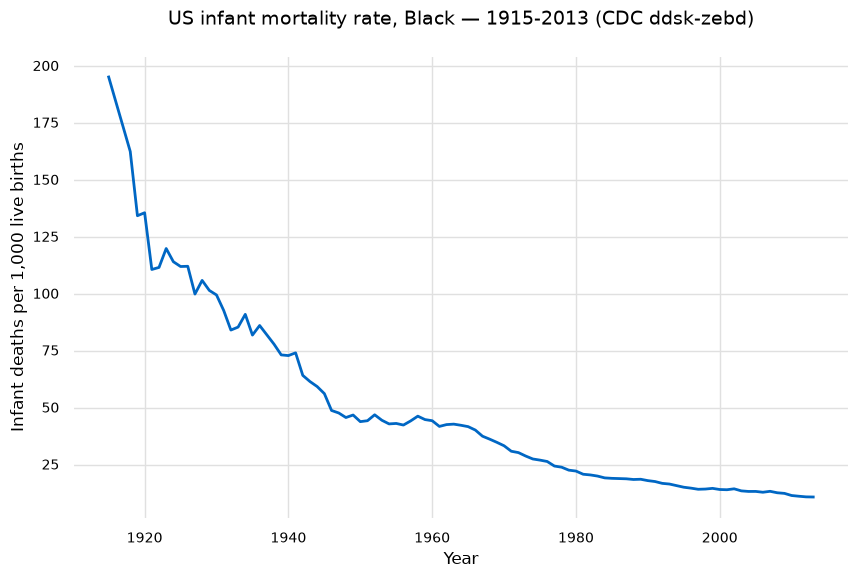

In [11]:
values, dates, dropped = cdc_rows_to_arrays_with_dropped(
    black.rows, "year", "infant_mortality_rate")

print(f"{len(values)} points, {dates[0].year}-{dates[-1].year},"
      f" {values.min()}..{values.max()} per 1,000 live births")
print(f"dropped {len(dropped)} of {black.row_count} rows: {dropped}")

plot_cdc_arrays(values, dates,
      title=f"US infant mortality rate, Black — {dates[0].year}-{dates[-1].year} (CDC {entry.id})",
      xlabel="Year", ylabel="Infant deaths per 1,000 live births")


### Drug overdose deaths, age-adjusted, 1999–2024 — WONDER

The stitched series: flat around 6 deaths per 100,000 through 1999–2001, a long
climb, then the COVID-era jump to the 2022 peak and a sharp fall through 2024.
Rates are age-adjusted to the 2000 US standard population, so the curve is not
an artefact of an ageing population.

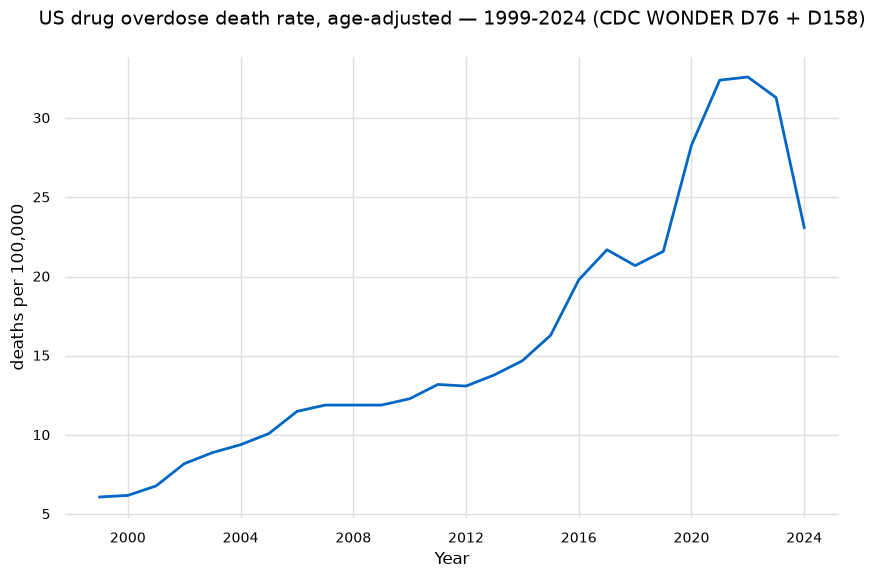

In [12]:
plot_stored_series(
    overdose.model_dump(),
    title="US drug overdose death rate, age-adjusted — 1999-2024 (CDC WONDER D76 + D158)",
)